In [1]:
import pandas as pd
import numpy as np
import os
import glob
import statsmodels.api as sm


In [2]:
# path to folder
folder_path = "./Task2Data/*.csv"

files = glob.glob(folder_path)

structural = {}
functional = {}

for file in files:
    name = os.path.basename(file)
    subject = name.split("_")[0]

    mat = pd.read_csv(file, comment='#', header=None).values

    if "WFA" in name:
        structural[subject] = mat
    elif "rsfMRI" in name:
        functional[subject] = mat

print(len(structural), len(functional))

19 19


In [3]:
import os
print(os.getcwd())

C:\Users\agroz\UCL\Comp Model for Bio Imaging\Connectomes project\connectomes-data


In [4]:
def indirect_connectivity(S):

    n = S.shape[0]
    T = np.zeros_like(S)

    for i in range(n):
        for j in range(n):

            if i == j:
                continue

            vals = []

            for k in range(n):

                if S[i,k] > 0 and S[k,j] > 0:
                    vals.append(min(S[i,k], S[k,j]))

            if vals:
                T[i,j] = max(vals)

    return T

In [5]:
T_matrices = {}

for subject in structural:

    S = structural[subject]
    T = indirect_connectivity(S)

    T_matrices[subject] = T

T_matrices


{'32': array([[0.        , 0.42255735, 0.40971658, ..., 0.        , 0.        ,
         0.42255735],
        [0.42255735, 0.        , 0.49604311, ..., 0.32162235, 0.46948489,
         0.45943316],
        [0.40971658, 0.49604311, 0.        , ..., 0.34516057, 0.46948489,
         0.43447875],
        ...,
        [0.        , 0.32162235, 0.34516057, ..., 0.        , 0.34516057,
         0.34516057],
        [0.        , 0.46948489, 0.46948489, ..., 0.34516057, 0.        ,
         0.42188022],
        [0.42255735, 0.45943316, 0.43447875, ..., 0.34516057, 0.42188022,
         0.        ]], shape=(68, 68)),
 '33': array([[0.        , 0.41149768, 0.43011361, ..., 0.        , 0.        ,
         0.43516083],
        [0.41149768, 0.        , 0.48380023, ..., 0.28125498, 0.49564331,
         0.44916189],
        [0.43011361, 0.48380023, 0.        , ..., 0.28125498, 0.48380023,
         0.48352925],
        ...,
        [0.        , 0.28125498, 0.28125498, ..., 0.        , 0.28125498,
      

In [6]:
subjects = list(structural.keys())
# Get the number of regions from one of the structural matrices
num_regions = structural[subjects[0]].shape[0]

## Refit All Models with AIC/BIC


In [7]:
def get_features(structural_data, indirect_structural_data, subjects, region_i, region_j,
                 include_s, include_t, include_s2, include_t2, include_interaction=False):
  exog = []
  if include_s:
    s_ij = np.array([structural_data[s][region_i, region_j] for s in subjects])
    exog.append(s_ij)
  if include_t:
    t_ij = np.array([indirect_structural_data[s][region_i, region_j] for s in subjects])
    exog.append(t_ij)
  if include_s2:
    if not include_s:
      s_ij = np.array([structural_data[s][region_i, region_j] for s in subjects])
    exog.append(s_ij**2)
  if include_t2:
    if not include_t:
      t_ij = np.array([indirect_structural_data[s][region_i, region_j] for s in subjects])
    exog.append(t_ij**2)
  if include_interaction:
    if not include_s:
      s_ij = np.array([structural_data[s][region_i, region_j] for s in subjects])
    if not include_t:
      t_ij = np.array([indirect_structural_data[s][region_i, region_j] for s in subjects])
    exog.append(s_ij * t_ij)
  return exog


def fit_generalized_model(functional_data, structural_data, indirect_structural_data,
                          subject_list, region_i, region_j,
                          include_s, include_t, include_s2, include_t2,
                          include_interaction=False):
    """
    Fits a generalized linear model for functional connectivity and returns coefficients, AIC, and BIC.

    Args:
        functional_data (dict): Dictionary of functional connectivity matrices per subject.
        structural_data (dict): Dictionary of structural connectivity matrices per subject.
        indirect_structural_data (dict): Dictionary of indirect structural connectivity
                                        matrices (T_matrices) per subject.
        subject_list (list): List of subject IDs.
        region_i (int): First brain region index.
        region_j (int): Second brain region index.
        include_s (bool): Whether to include direct structural connectivity (s_ij).
        include_t (bool): Whether to include indirect structural connectivity (t_ij).
        include_s2 (bool): Whether to include squared direct structural connectivity (s_ij^2).
        include_t2 (bool): Whether to include squared indirect structural connectivity (t_ij^2).
        include_interaction (bool): Whether to include interaction term (s_ij * t_ij).

    Returns:
        dict or None: A map, containing the parameters, aic and bic if
                               the model is fitted successfully, otherwise None.
    """

    f_ij = np.array([functional_data[s][region_i, region_j] for s in subject_list])

    exog_vars = get_features(
        structural_data, indirect_structural_data, subject_list,
        region_i, region_j,
        include_s, include_t, include_s2, include_t2, include_interaction
    )

    if not exog_vars or np.all(np.column_stack(exog_vars) == 0):
        return None

    X = np.column_stack(exog_vars)
    X = sm.add_constant(X)

    model = sm.OLS(f_ij, X).fit()

    return model

In [8]:
model1_results = {}
model2_results = {}
model3_results = {}
model4_results = {}
model5_results = {}
model6_results = {}

for i in range(num_regions):
    for j in range(num_regions):
        if i == j:
            continue

        # Model 1: fij = alpha_ij + beta_ij s_ij
        res1 = fit_generalized_model(
            functional, structural, T_matrices, subjects, i, j,
            include_s=True, include_t=False, include_s2=False, include_t2=False,
            include_interaction=False
        )
        if res1 is not None:
            model1_results[(i, j)] = res1

        # Model 2: fij = alpha_ij + beta_ij s_ij + gamma_ij s_ij^2
        res2 = fit_generalized_model(
            functional, structural, T_matrices, subjects, i, j,
            include_s=True, include_t=False, include_s2=True, include_t2=False,
            include_interaction=False
        )
        if res2 is not None:
            model2_results[(i, j)] = res2

        # Model 3: fij = alpha_ij + beta_ij t_ij
        res3 = fit_generalized_model(
            functional, structural, T_matrices, subjects, i, j,
            include_s=False, include_t=True, include_s2=False, include_t2=False,
            include_interaction=False
        )
        if res3 is not None:
            model3_results[(i, j)] = res3

        # Model 4: fij = alpha_ij + beta_ij t_ij + gamma_ij t_ij^2
        res4 = fit_generalized_model(
            functional, structural, T_matrices, subjects, i, j,
            include_s=False, include_t=True, include_s2=False, include_t2=True,
            include_interaction=False
        )
        if res4 is not None:
            model4_results[(i, j)] = res4

        # Model 5: fij = alpha_ij + beta_ij s_ij + gamma_ij t_ij
        res5 = fit_generalized_model(
            functional, structural, T_matrices, subjects, i, j,
            include_s=True, include_t=True, include_s2=False, include_t2=False,
            include_interaction=False
        )
        if res5 is not None:
            model5_results[(i, j)] = res5

        # Model 6: fij = alpha_ij + beta_ij s_ij + gamma_ij t_ij + delta_ij (s_ij * t_ij)
        res6 = fit_generalized_model(
            functional, structural, T_matrices, subjects, i, j,
            include_s=True, include_t=True, include_s2=False, include_t2=False,
            include_interaction=True
        )
        if res6 is not None:
            model6_results[(i, j)] = res6

print(f"Refitted models for {num_regions} regions.")
print(f"Example entry (0,2) Model 1 AIC: {model1_results[(0,2)].aic}")
print(f"Example entry (0,2) Model 6 AIC: {model6_results[(0,2)].aic}")

Refitted models for 68 regions.
Example entry (0,2) Model 1 AIC: -52.19583544402781
Example entry (0,2) Model 6 AIC: -49.52774884331549


## Implement Leave-One-Out Cross-Validation

In [9]:
def perform_loocv(functional_data, structural_data, indirect_structural_data,
                  subject_list, region_i, region_j,
                  include_s, include_t, include_s2, include_t2,
                  include_interaction=False):
    """
    Evaluates model predictive performance using Leave-One-Out Cross-Validation (LOOCV).
    Returns the total Sum of Squared Errors (SSE) across all subjects.
    """
    total_sse = 0
    num_subjects = len(subject_list)

    for idx in range(num_subjects):
        # Define training and test subjects
        test_subject = subject_list[idx]
        train_subjects = [s for i, s in enumerate(subject_list) if i != idx]

        # Fit model on training set
        model = fit_generalized_model(
            functional_data, structural_data, indirect_structural_data,
            train_subjects, region_i, region_j,
            include_s, include_t, include_s2, include_t2,
            include_interaction
        )
        if model is None:
            continue

        # Prepare test data
        y_test = functional_data[test_subject][region_i, region_j]

        X_test_raw = get_features(
            structural_data, indirect_structural_data,
            [test_subject], region_i, region_j,
            include_s, include_t, include_s2, include_t2,
            include_interaction
        )

        if not X_test_raw:
            continue

        X_test_raw = np.column_stack(X_test_raw)
        X_test = sm.add_constant(X_test_raw, has_constant='add')

        # Predict and calculate squared error
        prediction = model.predict(X_test)[0]
        squared_error = (y_test - prediction) ** 2
        total_sse += squared_error

    return total_sse

## Calculate SSE for All Models

### Subtask:
Iterate through all brain region pairs and compute the total Sum of Squared Errors (SSE) for each of the five models using the perform_loocv function.


**Reasoning**:
I will initialize the SSE dictionaries and iterate through all brain region pairs to compute the LOOCV SSE for all five models using the previously defined perform_loocv function.



In [10]:
sse_model1 = {}
sse_model2 = {}
sse_model3 = {}
sse_model4 = {}
sse_model5 = {}
sse_model6 = {}

for i in range(num_regions):
    for j in range(num_regions):
        if i == j:
            continue

        # Model 1: s_ij
        sse1 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=True, include_t=False, include_s2=False, include_t2=False,
                             include_interaction=False)
        if sse1 is not None:
            sse_model1[(i, j)] = sse1

        # Model 2: s_ij + s_ij^2
        sse2 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=True, include_t=False, include_s2=True, include_t2=False,
                             include_interaction=False)
        if sse2 is not None:
            sse_model2[(i, j)] = sse2

        # Model 3: t_ij
        sse3 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=False, include_t=True, include_s2=False, include_t2=False,
                             include_interaction=False)
        if sse3 is not None:
            sse_model3[(i, j)] = sse3

        # Model 4: t_ij + t_ij^2
        sse4 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=False, include_t=True, include_s2=False, include_t2=True,
                             include_interaction=False)
        if sse4 is not None:
            sse_model4[(i, j)] = sse4

        # Model 5: s_ij + t_ij
        sse5 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=True, include_t=True, include_s2=False, include_t2=False,
                             include_interaction=False)
        if sse5 is not None:
            sse_model5[(i, j)] = sse5

        # Model 6: s_ij + t_ij + s_ij * t_ij
        sse6 = perform_loocv(functional, structural, T_matrices, subjects, i, j,
                             include_s=True, include_t=True, include_s2=False, include_t2=False,
                             include_interaction=True)
        if sse6 is not None:
            sse_model6[(i, j)] = sse6

print(f"LOOCV SSE calculation completed for {num_regions} regions.")

LOOCV SSE calculation completed for 68 regions.


## Plot Model Comparison


C:\Users\agroz\AppData\Local\Temp\ipykernel_20432\844613857.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparison_df, x='Model', y='AIC', ax=axes[0], palette='Set2')
C:\Users\agroz\AppData\Local\Temp\ipykernel_20432\844613857.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparison_df, x='Model', y='BIC', ax=axes[1], palette='Set2')
C:\Users\agroz\AppData\Local\Temp\ipykernel_20432\844613857.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparison_df, x='Model', y='SSE', ax=axes[2], palette='Set2')


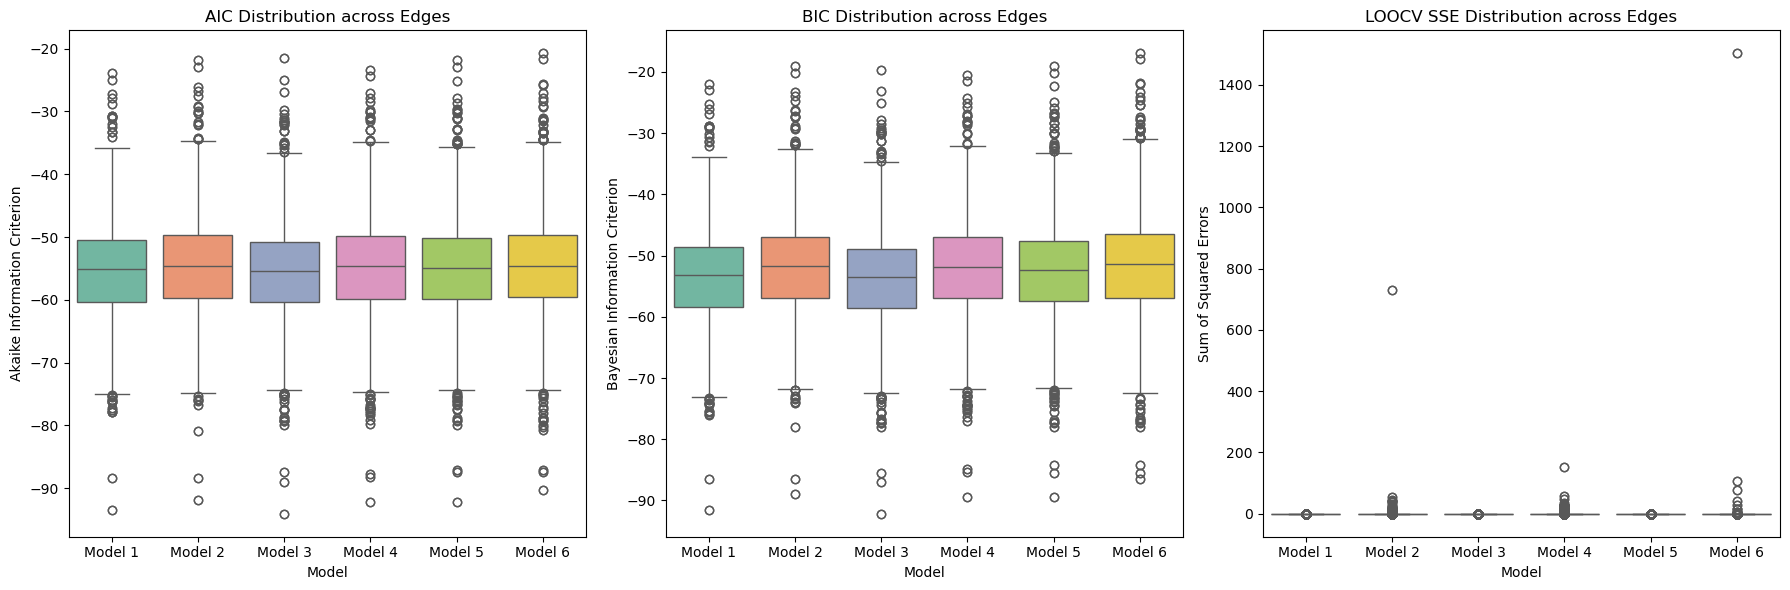

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data lists for AIC, BIC, and SSE
data = []

model_names = ['Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5', 'Model 6']
res_dicts = [model1_results, model2_results, model3_results, model4_results, model5_results, model6_results]
sse_dicts = [sse_model1, sse_model2, sse_model3, sse_model4, sse_model5, sse_model6]

for idx, m_name in enumerate(model_names):
    current_res = res_dicts[idx]
    current_sse = sse_dicts[idx]

    # Get common keys (edges) present in both results and SSE for consistency
    common_keys = set(current_res.keys()) & set(current_sse.keys())

    for key in common_keys:
        data.append({
            'Model': m_name,
            'AIC': current_res[key].aic,
            'BIC': current_res[key].bic,
            'SSE': current_sse[key]
        })

# Create DataFrame
comparison_df = pd.DataFrame(data)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# AIC Box Plot
sns.boxplot(data=comparison_df, x='Model', y='AIC', ax=axes[0], palette='Set2')
axes[0].set_title('AIC Distribution across Edges')
axes[0].set_ylabel('Akaike Information Criterion')

# BIC Box Plot
sns.boxplot(data=comparison_df, x='Model', y='BIC', ax=axes[1], palette='Set2')
axes[1].set_title('BIC Distribution across Edges')
axes[1].set_ylabel('Bayesian Information Criterion')

# SSE Box Plot
sns.boxplot(data=comparison_df, x='Model', y='SSE', ax=axes[2], palette='Set2')
axes[2].set_title('LOOCV SSE Distribution across Edges')
axes[2].set_ylabel('Sum of Squared Errors')

plt.tight_layout()
plt.show()